Merging all model results...

--- FINAL MODEL PERFORMANCE RANKING ---
             Model  AUPRC (Primary)  ROC-AUC Min Cost/Tx  Optimal Threshold
               lgb         0.592236 0.907693       $2.16               0.01
               xgb         0.534099 0.881985       $2.10               0.01
          mlp_prob         0.350340 0.848342       $2.05               0.09
               iso         0.099678 0.772263       $2.28               0.01
ae_semi_supervised         0.066925 0.712743      $16.99               0.61
     ae_supervised         0.063834 0.704757      $16.99               0.91
               lof         0.041492 0.560784      $16.86               0.01

Error analysis completed for lgb.
Files saved: 'final_pr_curves.png', 'final_model_comparison_table.csv', 'top_10_false_positives.csv', 'top_10_false_negatives.csv'


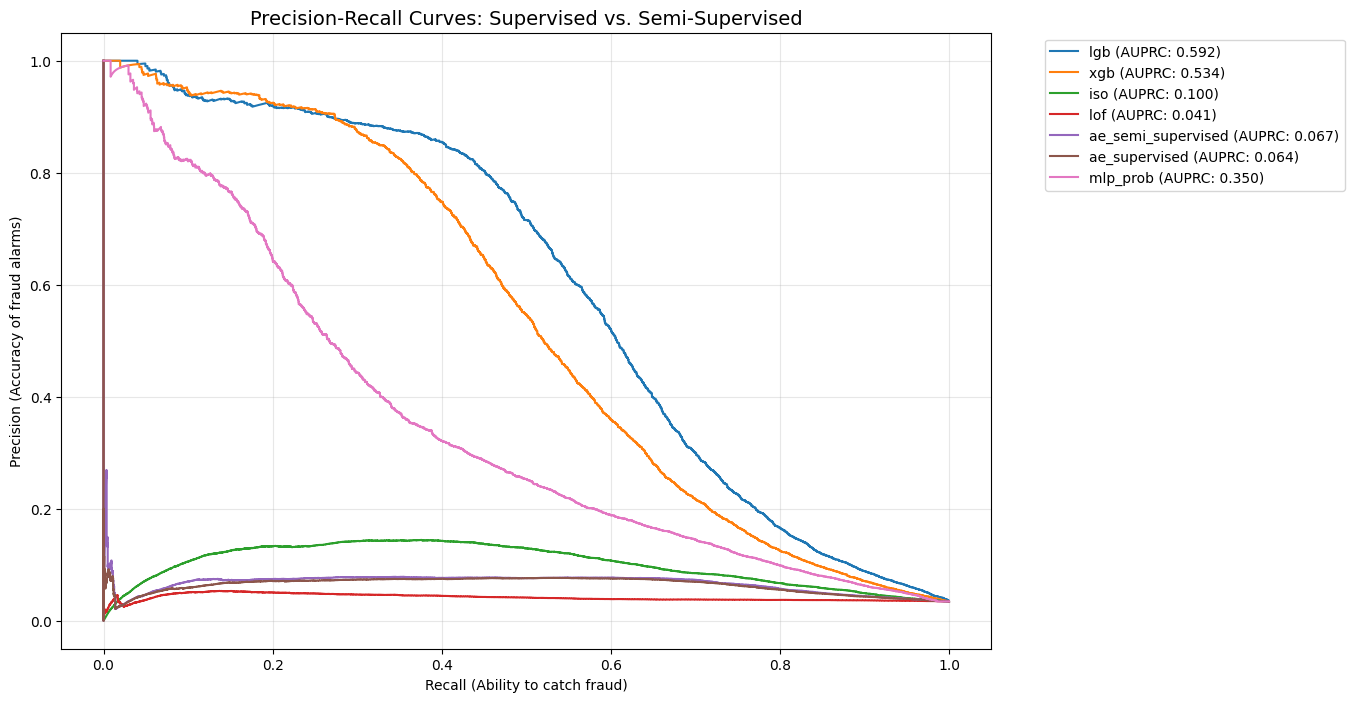

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score, confusion_matrix

# 1. LOAD AND MERGE
print("Merging all model results...")
ml_df = pd.read_csv('results/all_ml_probs.csv')
dl_df = pd.read_csv('results/dl_results.csv')
impact_df = pd.read_csv('results/feature_impact_results.csv')

# Combine into one master dataframe 
df = pd.concat([ml_df, dl_df.drop('actual', axis=1)], axis=1)

# Identify models (exclude the target)
models = [col for col in df.columns if col != 'actual']

# 2. COST-SENSITIVE EVALUATION ($500 FN vs $2 FP)
def calculate_business_cost(y_true, y_prob):
    thresholds = np.linspace(0.01, 0.99, 99)
    costs = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        fn = ((y_true == 1) & (y_pred == 0)).sum()
        fp = ((y_true == 0) & (y_pred == 1)).sum()
        # Total cost logic from rubric
        total_cost = (fn * 500) + (fp * 2)
        costs.append(total_cost / len(y_true)) 
    return thresholds, costs

# 3. GENERATE SUMMARY PERFORMANCE TABLE
summary_stats = []
plt.figure(figsize=(12, 8))

for m in models:
    # Autoencoder and Isolation Forest scores often need inversion if they represent "outlierness" 
    # but here we treat high = more likely fraud
    y_prob = df[m]
    
    # Standardize score ranges for metrics if necessary
    if y_prob.max() > 1.0 or y_prob.min() < 0:
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())
    
    aup_score = average_precision_score(df['actual'], y_prob)
    auc_score = roc_auc_score(df['actual'], y_prob)
    
    # Calculate optimal business cost
    thresh, costs = calculate_business_cost(df['actual'], y_prob)
    min_cost = np.min(costs)
    opt_thresh = thresh[np.argmin(costs)]
    
    summary_stats.append({
        'Model': m,
        'AUPRC (Primary)': aup_score,
        'ROC-AUC': auc_score,
        'Min Cost/Tx': f"${min_cost:.2f}",
        'Optimal Threshold': opt_thresh
    })
    
    # Plot PR Curve
    precision, recall, _ = precision_recall_curve(df['actual'], y_prob)
    plt.plot(recall, precision, label=f'{m} (AUPRC: {aup_score:.3f})')

# Formatting the PR Curve
plt.title('Precision-Recall Curves: Supervised vs. Semi-Supervised', fontsize=14)
plt.xlabel('Recall (Ability to catch fraud)')
plt.ylabel('Precision (Accuracy of fraud alarms)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.savefig('report/final_pr_curves.png', bbox_inches='tight')

# 4. SHOW FINAL TABLE
results_table = pd.DataFrame(summary_stats).sort_values(by='AUPRC (Primary)', ascending=False)
print("\n--- FINAL MODEL PERFORMANCE RANKING ---")
print(results_table.to_string(index=False))
results_table.to_csv('report/final_model_comparison_table.csv', index=False)

# 5. CONFIDENT ERROR ANALYSIS (Manual Review)
# We use the top-performing model (likely LightGBM or MLP)
best_model_name = results_table.iloc[0]['Model']
df['prob'] = df[best_model_name]

# Confident False Positives: Model is 90%+ sure it's fraud, but it's not.
false_positives = df[(df['actual'] == 0)].sort_values(by='prob', ascending=False).head(10)

# Confident False Negatives: Model is 90%+ sure it's NOT fraud, but it is.
false_negatives = df[(df['actual'] == 1)].sort_values(by='prob', ascending=True).head(10)

false_positives.to_csv('report/top_10_false_positives.csv')
false_negatives.to_csv('report/top_10_false_negatives.csv')

print(f"\nError analysis completed for {best_model_name}.")
print("Files saved: 'final_pr_curves.png', 'final_model_comparison_table.csv', 'top_10_false_positives.csv', 'top_10_false_negatives.csv'")

F1-optimal threshold:   0.78  (F1 = 0.5257)
Cost-optimal threshold: 0.04  (Cost/Tx = $1.46)


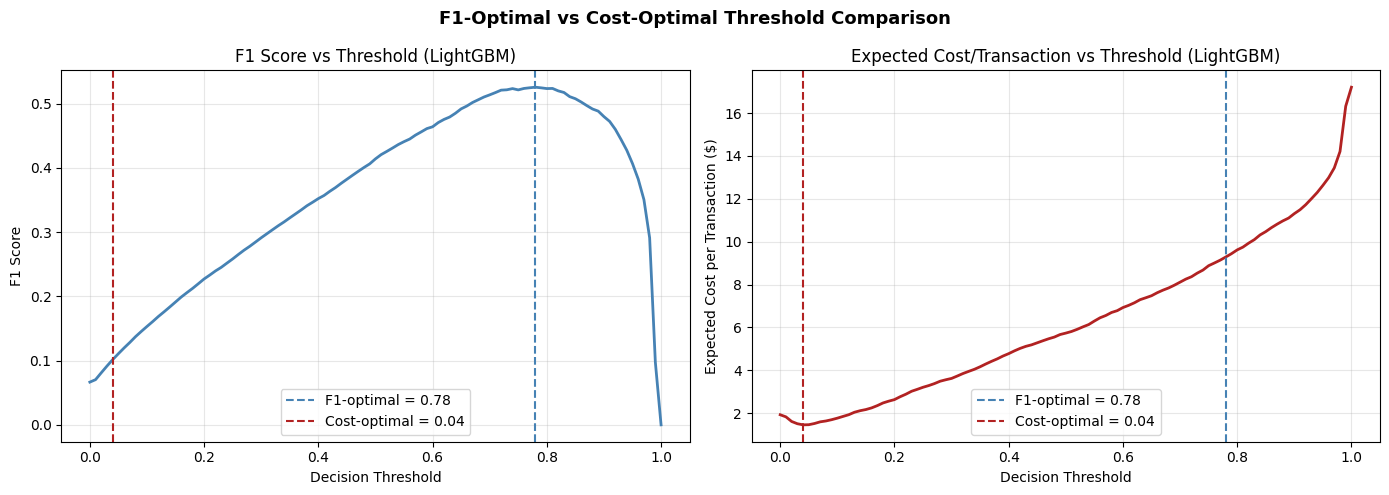


--- Threshold Comparison Summary ---
Criterion                  Threshold       F1    Cost/Tx
-------------------------------------------------------
Maximise F1                     0.78   0.5257 $     9.29
Minimise Cost                   0.04   0.1015 $     1.46


In [2]:
from sklearn.metrics import f1_score, precision_recall_fscore_support

# Use best model (LightGBM)
best_model_name = results_table.iloc[0]['Model']  # 'lgb'
y_prob = df[best_model_name].values
y_true = df['actual'].values

thresholds = np.linspace(0, 1, 101)

f1_scores = []
costs = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    
    # F1
    f1 = f1_score(y_true, y_pred, zero_division=0)
    f1_scores.append(f1)
    
    # Cost
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    costs.append((fn * 500 + fp * 2) / len(y_true))

f1_scores = np.array(f1_scores)
costs = np.array(costs)

best_f1_thresh   = thresholds[np.argmax(f1_scores)]
best_cost_thresh = thresholds[np.argmin(costs)]

print(f"F1-optimal threshold:   {best_f1_thresh:.2f}  (F1 = {f1_scores.max():.4f})")
print(f"Cost-optimal threshold: {best_cost_thresh:.2f}  (Cost/Tx = ${costs.min():.2f})")

# Side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# F1 curve
ax1.plot(thresholds, f1_scores, color='steelblue', linewidth=2)
ax1.axvline(best_f1_thresh, color='steelblue', linestyle='--', label=f'F1-optimal = {best_f1_thresh:.2f}')
ax1.axvline(best_cost_thresh, color='firebrick', linestyle='--', label=f'Cost-optimal = {best_cost_thresh:.2f}')
ax1.set_title('F1 Score vs Threshold (LightGBM)')
ax1.set_xlabel('Decision Threshold')
ax1.set_ylabel('F1 Score')
ax1.legend()
ax1.grid(alpha=0.3)

# Cost curve
ax2.plot(thresholds, costs, color='firebrick', linewidth=2)
ax2.axvline(best_f1_thresh, color='steelblue', linestyle='--', label=f'F1-optimal = {best_f1_thresh:.2f}')
ax2.axvline(best_cost_thresh, color='firebrick', linestyle='--', label=f'Cost-optimal = {best_cost_thresh:.2f}')
ax2.set_title('Expected Cost/Transaction vs Threshold (LightGBM)')
ax2.set_xlabel('Decision Threshold')
ax2.set_ylabel('Expected Cost per Transaction ($)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('F1-Optimal vs Cost-Optimal Threshold Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('report/threshold_comparison.png', bbox_inches='tight')
plt.show()

# Summary table
print("\n--- Threshold Comparison Summary ---")
print(f"{'Criterion':<25} {'Threshold':>10} {'F1':>8} {'Cost/Tx':>10}")
print("-" * 55)
f1_at_cost = f1_scores[np.argmin(costs)]
cost_at_f1 = costs[np.argmax(f1_scores)]
print(f"{'Maximise F1':<25} {best_f1_thresh:>10.2f} {f1_scores.max():>8.4f} ${cost_at_f1:>9.2f}")
print(f"{'Minimise Cost':<25} {best_cost_thresh:>10.2f} {f1_at_cost:>8.4f} ${costs.min():>9.2f}")

# Dataset 2: PaySim

## PaySim Results Analysis and Comparison

Dataset: PaySim Fraud Detection

This section combines the PaySim machine learning and deep learning outputs, ranks all models by primary performance metric (AUPRC), evaluates cost-sensitive performance, and exports report-ready tables and figures.

Merging all PaySim model results...


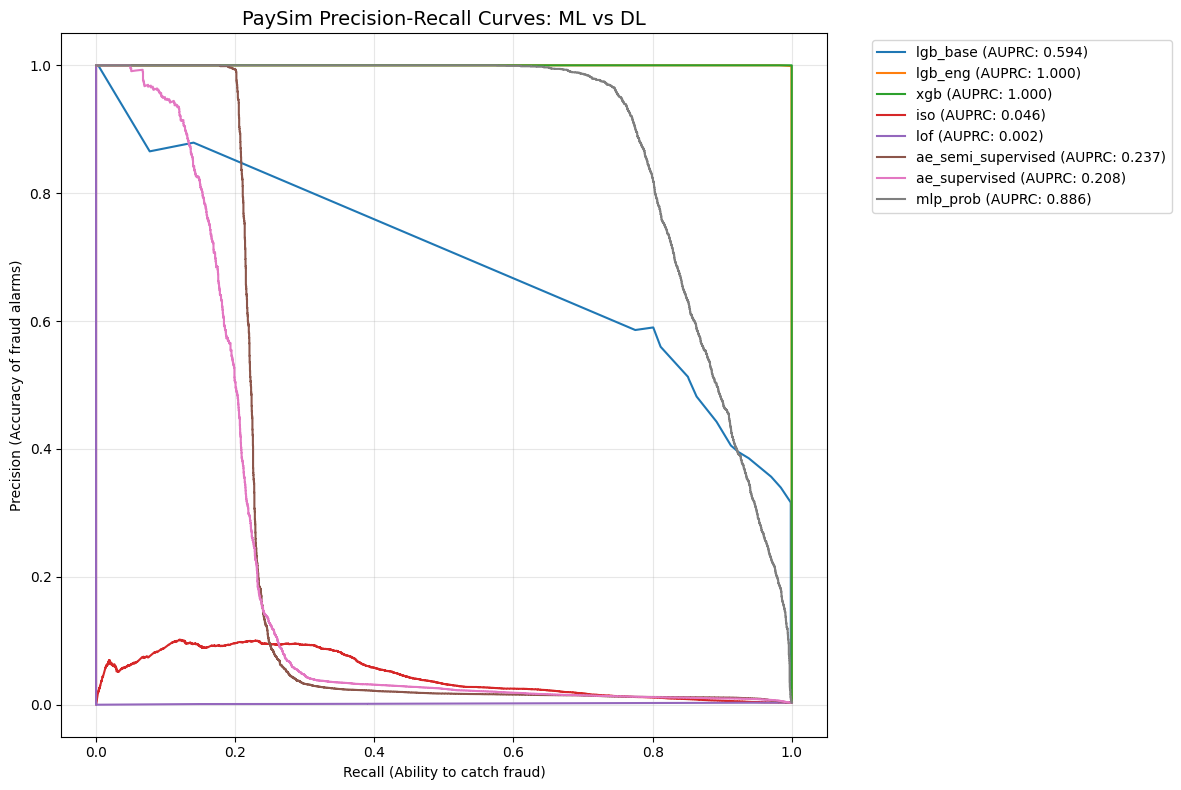


--- PAYSIM FINAL MODEL PERFORMANCE RANKING ---
             Model  AUPRC (Primary)  ROC-AUC Min Cost/Tx  Optimal Threshold
               xgb         1.000000 1.000000       $0.00               0.15
           lgb_eng         0.999517 0.999950       $0.00               0.01
          mlp_prob         0.886387 0.997747       $0.06               0.02
          lgb_base         0.593770 0.998001       $0.02               0.01
ae_semi_supervised         0.237070 0.875687       $1.67               0.01
     ae_supervised         0.207831 0.880911       $1.67               0.01
               iso         0.045732 0.850029       $0.76               0.10
               lof         0.001847 0.181138       $1.67               1.00

Error analysis completed for xgb.
Files saved: 'paysim_final_pr_curves.png', 'paysim_final_model_comparison_table.csv', 'paysim_top_10_false_positives.csv', 'paysim_top_10_false_negatives.csv'


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score, confusion_matrix

# 1. LOAD AND MERGE PAYSIM RESULTS
print("Merging all PaySim model results...")

ml_df = pd.read_csv('results/paysim_all_ml_probs.csv')
dl_df = pd.read_csv('results/paysim_dl_results.csv')
impact_df = pd.read_csv('results/paysim_feature_impact_results.csv')

# Combine into one master dataframe
df = pd.concat([ml_df, dl_df.drop(columns=['actual'], errors='ignore')], axis=1)

# Identify models (exclude target)
models = [col for col in df.columns if col != 'actual']

# 2. COST-SENSITIVE EVALUATION
def calculate_business_cost(y_true, y_prob):
    thresholds = np.linspace(0, 1, 101)
    costs = []
    
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        fn = ((y_true == 1) & (y_pred == 0)).sum()
        fp = ((y_true == 0) & (y_pred == 1)).sum()
        
        # same business rule as IEEE notebook
        total_cost = (fn * 500) + (fp * 2)
        costs.append(total_cost / len(y_true))
        
    return thresholds, costs

# 3. GENERATE SUMMARY PERFORMANCE TABLE
summary_stats = []

plt.figure(figsize=(12, 8))

for m in models:
    y_prob = df[m].copy()

    # Standardize score ranges if necessary
    if y_prob.max() > 1.0 or y_prob.min() < 0:
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min() + 1e-12)

    aup_score = average_precision_score(df['actual'], y_prob)
    auc_score = roc_auc_score(df['actual'], y_prob)

    # Calculate optimal business cost
    thresh, costs = calculate_business_cost(df['actual'], y_prob)
    min_cost = np.min(costs)
    opt_thresh = thresh[np.argmin(costs)]

    summary_stats.append({
        'Model': m,
        'AUPRC (Primary)': aup_score,
        'ROC-AUC': auc_score,
        'Min Cost/Tx': f"${min_cost:.2f}",
        'Optimal Threshold': opt_thresh
    })

    # Plot PR Curve
    precision, recall, _ = precision_recall_curve(df['actual'], y_prob)
    plt.plot(recall, precision, label=f'{m} (AUPRC: {aup_score:.3f})')

# Formatting the PR Curve
plt.title('PaySim Precision-Recall Curves: ML vs DL', fontsize=14)
plt.xlabel('Recall (Ability to catch fraud)')
plt.ylabel('Precision (Accuracy of fraud alarms)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('report/paysim_final_pr_curves.png', bbox_inches='tight')
plt.show()

# 4. SHOW FINAL TABLE
results_table = pd.DataFrame(summary_stats).sort_values(by='AUPRC (Primary)', ascending=False)
print("\n--- PAYSIM FINAL MODEL PERFORMANCE RANKING ---")
print(results_table.to_string(index=False))

results_table.to_csv('report/paysim_final_model_comparison_table.csv', index=False)

# 5. CONFIDENT ERROR ANALYSIS
best_model_name = results_table.iloc[0]['Model']
df['prob'] = df[best_model_name].copy()

# normalize again if needed
if df['prob'].max() > 1.0 or df['prob'].min() < 0:
    df['prob'] = (df['prob'] - df['prob'].min()) / (df['prob'].max() - df['prob'].min() + 1e-12)

false_positives = df[df['actual'] == 0].sort_values(by='prob', ascending=False).head(10)
false_negatives = df[df['actual'] == 1].sort_values(by='prob', ascending=True).head(10)

false_positives.to_csv('report/paysim_top_10_false_positives.csv', index=False)
false_negatives.to_csv('report/paysim_top_10_false_negatives.csv', index=False)

print(f"\nError analysis completed for {best_model_name}.")
print("Files saved: 'paysim_final_pr_curves.png', 'paysim_final_model_comparison_table.csv', 'paysim_top_10_false_positives.csv', 'paysim_top_10_false_negatives.csv'")

The precision-recall curves indicate near-perfect classification performance for tree-based models (LightGBM and XGBoost), with AUPRC values approaching 1.0. This reflects the highly structured and synthetic nature of the PaySim dataset, where fraud patterns are strongly separable. In contrast, deep learning models such as MLP exhibit slightly lower but still strong performance, while unsupervised approaches (Isolation Forest, LOF, Autoencoders) show significantly weaker discrimination ability.